Código para descargar el dataset

In [ ]:
!wget https://raw.githubusercontent.com/SenticNet/personality-detection/master/essays.csv

--2026-06-04 14:33:22--  https://raw.githubusercontent.com/SenticNet/personality-detection/master/essays.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8206858 (7.8M) [application/octet-stream]
Saving to: ‘essays.csv’

essays.csv          100%[===================>]   7.83M  --.-KB/s    in 0.07s   

2026-06-04 14:33:23 (111 MB/s) - ‘essays.csv’ saved [8206858/8206858]



Código para leer el contenido de csv

In [ ]:
import pandas as pd

# Cargar el dataset (usamos encoding cp1252 por los caracteres especiales del texto original)
df = pd.read_csv('essays.csv', encoding='cp1252')

# Mostrar las primeras 5 filas para comprobar que ha funcionado
df.head()

,#AUTHID,TEXT,cEXT,cNEU,cAGR,cCON,cOPN
0,1997_504851.txt,"Well, right now I just woke up from a mid-day ...",n,y,y,n,y
1,1997_605191.txt,"Well, here we go with the stream of consciousn...",n,n,y,n,n
2,1997_687252.txt,An open keyboard and buttons to push. The thin...,n,y,n,y,y
3,1997_568848.txt,I can't believe it! It's really happening! M...,y,n,y,y,n
4,1997_688160.txt,"Well, here I go with the good old stream of co...",y,n,y,n,y


Preparamenos los datos para poder trabajar con ellos. Aplicaremos EDA

In [ ]:
# Renombrar columnas para que sean más claras
df = df.rename(columns={
    'cEXT': 'Extroversion',
    'cNEU': 'Neuroticism',
    'cAGR': 'Agreeableness',
    'cCON': 'Conscientiousness',
    'cOPN': 'Openness'
})

# Convertir 'y' en 1 y 'n' en 0
rasgos = ['Extroversion', 'Neuroticism', 'Agreeableness', 'Conscientiousness', 'Openness']
for rasgo in rasgos:
    df[rasgo] = df[rasgo].map({'y': 1, 'n': 0})

df.head()

,#AUTHID,TEXT,Extroversion,Neuroticism,Agreeableness,Conscientiousness,Openness
0,1997_504851.txt,"Well, right now I just woke up from a mid-day ...",0,1,1,0,1
1,1997_605191.txt,"Well, here we go with the stream of consciousn...",0,0,1,0,0
2,1997_687252.txt,An open keyboard and buttons to push. The thin...,0,1,0,1,1
3,1997_568848.txt,I can't believe it! It's really happening! M...,1,0,1,1,0
4,1997_688160.txt,"Well, here I go with the good old stream of co...",1,0,1,0,1


Estudiamos la distribución de los datos

In [ ]:
print(f"Total de ensayos en el dataset: {len(df)}\n")

print("Porcentaje de personas que dan positivo (1) en cada rasgo:")
# Al calcular la media de 0s y 1s, obtenemos el porcentaje directamente
print((df[rasgos].mean() * 100).round(2).astype(str) + ' %')

Total de ensayos en el dataset: 2467

Porcentaje de personas que dan positivo (1) en cada rasgo:
Extroversion         51.72 %
Neuroticism          49.98 %
Agreeableness         53.1 %
Conscientiousness    50.79 %
Openness             51.52 %
dtype: object


Separamos 500 registros para el Test de los modelos

In [ ]:
from sklearn.model_selection import train_test_split

# Separamos 500 textos para el test.
# random_state=42 asegura que si vuelves a ejecutarlo, siempre seleccione los mismos 500.
df_train, df_test = train_test_split(df, test_size=500, random_state=42)

print(f"Textos guardados para entrenar nuestro propio modelo: {len(df_train)}")
print(f"Textos aislados para evaluar y retar a las IAs: {len(df_test)}")

Textos guardados para entrenar nuestro propio modelo: 1967
Textos aislados para evaluar y retar a las IAs: 500


Guardaremos los datos en 2 csv en drive para que no se pierdan

In [ ]:
from google.colab import drive
import os

# Conectar con Google Drive
drive.mount('/content/drive')

# Crear la ruta de la carpeta (si no existe)
ruta_carpeta = '/content/drive/MyDrive/TFM_Personalidad'
os.makedirs(ruta_carpeta, exist_ok=True)

# Guardar los archivos
df_train.to_csv(f'{ruta_carpeta}/train_personalidad.csv', index=False)
df_test.to_csv(f'{ruta_carpeta}/test_personalidad.csv', index=False)

print("¡Archivos guardados con éxito en tu Google Drive!")

Mounted at /content/drive
¡Archivos guardados con éxito en tu Google Drive!


Vamos a sacar un único texto del conjunto de prueba

In [ ]:
# Seleccionar la primera fila del conjunto de test
sujeto_prueba = df_test.iloc[0]

texto_sujeto = sujeto_prueba['TEXT']
valores_reales = sujeto_prueba[['Extroversion', 'Neuroticism', 'Agreeableness', 'Conscientiousness', 'Openness']].to_dict()

print("--- TEXTO DEL USUARIO ---")
print(texto_sujeto)
print("\n--- VALORES REALES (Ground Truth) ---")
print(valores_reales)

--- TEXTO DEL USUARIO ---
     Im not sure where to start at thinking. Of course I'm used to   thinking and all. I guess. I am really sleep right now. I am always   sleepy. oh, and im so used to not doing the correct english thing.  like with caps and punctuation and all. i hope that doesnt take off   from grading. oh well. when i first signed in my native instinct was to   sign onto aim. i always do that. i love talking to my friends. i miss   them so much. im sure ill find some here that are great and i will   never want to let them go. but for now, the computer chat thing will   do. oh!! im so excited because one of my good friends that i met   probably one month before i came here is suppose to visit right   before thanksgiving holiday. he'll probably stay here for two nights   then come back to longview with me and my sister. hopefully. im   really excited about tonight. me and two of my friends from high   school are going to the concert thing at 7:20! i can't wait. i can't wait.

Instalar las librerías de las tres IAs

In [ ]:
!pip install -q google-generativeai groq cohere

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 352.0/352.0 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 78.4 MB/s eta 0:00:00


Cargar las claves en la memoria del código

In [ ]:
import os
from google.colab import userdata

# Recuperar las claves de la bóveda de forma segura
try:
    GEMINI_KEY = userdata.get('GEMINI_API_KEY')
    GROQ_KEY = userdata.get('GROQ_API_KEY')
    COHERE_KEY = userdata.get('COHERE_API_KEY')
    print("¡Éxito! Las 3 claves se han cargado correctamente en el entorno.")
except userdata.SecretNotFoundError as e:
    print(f"Error: No se ha encontrado el secreto {e}. Revisa el Paso 13 y asegúrate de haber activado el interruptor.")

¡Éxito! Las 3 claves se han cargado correctamente en el entorno.


Inicializar los "Clientes" de las APIs

In [ ]:
!pip install -q google-genai

In [ ]:
from google import genai
from groq import Groq
import cohere

# 1. Configurar Gemini
client_gemini = genai.Client(api_key=GEMINI_KEY)
modelo_gemini = "gemini-2.5-flash"

# 2. Configurar Groq (Actualizamos a Llama 3.3 70B, que es el actual soportado y muy potente)
cliente_groq = Groq(api_key=GROQ_KEY)
modelo_llama = "llama-3.3-70b-versatile"

# 3. Configurar Cohere
cliente_cohere = cohere.Client(api_key=COHERE_KEY)

print("¡Los tres clientes de IA están configurados con los modelos vigentes!")

¡Los tres clientes de IA están configurados con los modelos vigentes!


Declaramos el Prompt

In [ ]:
prompt_psicologico = """Eres un experto en psicometría computacional. Tu tarea es analizar el texto escrito por un usuario y predecir su perfil de personalidad basándote en el modelo de los Cinco Grandes (Big Five).
Evalúa el texto y determina si el autor puntúa alto (1) o bajo (0) en cada uno de los siguientes rasgos: Extroversion, Neuroticism, Agreeableness, Conscientiousness, Openness.
Debes responder ÚNICAMENTE con un objeto JSON válido, sin formato markdown, sin texto adicional, con esta estructura exacta:
{"Extroversion": 0, "Neuroticism": 1, "Agreeableness": 1, "Conscientiousness": 0, "Openness": 1}"""

Probamos con Gemini

In [ ]:
def evaluar_con_gemini_actualizado(texto):
    prompt_completo = f"{prompt_psicologico}\n\nTexto del usuario:\n{texto}"

    # Nueva sintaxis oficial de llamada
    respuesta = client_gemini.models.generate_content(
        model=modelo_gemini,
        contents=prompt_completo,
    )

    return respuesta.text.strip()

# Repetimos la prueba de fuego
resultado_prueba = evaluar_con_gemini_actualizado(texto_sujeto)

print("--- PREDICCIÓN DE GEMINI (CON LIBRERÍA MODERNA) ---")
print(resultado_prueba)

--- PREDICCIÓN DE GEMINI (CON LIBRERÍA MODERNA) ---
{"Extroversion": 1, "Neuroticism": 0, "Agreeableness": 1, "Conscientiousness": 0, "Openness": 1}


In [ ]:
import json
import re

def limpiar_y_leer_json(texto_respuesta):
    try:
        # Intentar leerlo directamente
        return json.loads(texto_respuesta)
    except json.JSONDecodeError:
        # Si falla, buscar un patrón JSON usando expresiones regulares
        match = re.search(r'\{.*?\}', texto_respuesta, re.DOTALL)
        if match:
            try:
                return json.loads(match.group(0))
            except:
                pass
        # Si todo falla, devolvemos un diccionario con valores nulos
        return {"Extroversion": None, "Neuroticism": None, "Agreeableness": None, "Conscientiousness": None, "Openness": None}

Evaluamos las 3 IAs

In [ ]:
def evaluar_con_llama(texto):
    # La mantenemos igual, Groq usa la variable modelo_llama que ya arreglamos
    respuesta = cliente_groq.chat.completions.create(
        messages=[
            {"role": "system", "content": prompt_psicologico},
            {"role": "user", "content": f"Texto del usuario:\n{texto}"}
        ],
        model=modelo_llama,
        temperature=0.0
    )
    return respuesta.choices[0].message.content.strip()

def evaluar_con_cohere(texto):
    # Actualizamos el modelo al vigente (Command-R Plus u otro reciente)
    respuesta = cliente_cohere.chat(
        message=f"Texto del usuario:\n{texto}",
        preamble=prompt_psicologico,
        model="command-r-plus-08-2024", # El modelo actual
        temperature=0.0
    )
    return respuesta.text.strip()

In [ ]:
print("Evaluando con Gemini...")
res_gemini = limpiar_y_leer_json(evaluar_con_gemini_actualizado(texto_sujeto))

print("Evaluando con Llama 3 (Groq)...")
res_llama = limpiar_y_leer_json(evaluar_con_llama(texto_sujeto))

print("Evaluando con Command-R (Cohere)...")
res_cohere = limpiar_y_leer_json(evaluar_con_cohere(texto_sujeto))

print("\n--- RESULTADOS COMPARADOS ---")
print(f"Valores Reales : {valores_reales}")
print(f"Gemini         : {res_gemini}")
print(f"Llama 3        : {res_llama}")
print(f"Command-R      : {res_cohere}")

Evaluando con Gemini...
Evaluando con Llama 3 (Groq)...
Evaluando con Command-R (Cohere)...

--- RESULTADOS COMPARADOS ---
Valores Reales : {'Extroversion': 0, 'Neuroticism': 0, 'Agreeableness': 1, 'Conscientiousness': 0, 'Openness': 0}
Gemini         : {'Extroversion': 1, 'Neuroticism': 1, 'Agreeableness': 1, 'Conscientiousness': 0, 'Openness': 1}
Llama 3        : {'Extroversion': 1, 'Neuroticism': 0, 'Agreeableness': 1, 'Conscientiousness': 0, 'Openness': 1}
Command-R      : {'Extroversion': 1, 'Neuroticism': 0, 'Agreeableness': 1, 'Conscientiousness': 0, 'Openness': 1}


Preparar la barra de progreso y los retardos

In [ ]:
import time
from tqdm import tqdm
import json

print("Herramientas de automatización listas.")

Herramientas de automatización listas.


El Bucle de Evaluación Masiva

In [ ]:
# Hacemos una copia para no romper los datos originales
df_benchmark = df_test.copy()

# Listas para guardar las respuestas de cada IA
predicciones_gemini = []
predicciones_llama = []
predicciones_cohere = []

print("Iniciando evaluación comercial masiva. Por favor, no cierres esta pestaña...")

# Recorremos los 500 textos uno a uno con una barra de progreso
for index, row in tqdm(df_benchmark.iterrows(), total=len(df_benchmark)):
    texto = row['TEXT']

    # 1. Gemini
    try:
        res_g = limpiar_y_leer_json(evaluar_con_gemini_actualizado(texto))
    except Exception:
        res_g = {"Error": True} # Por si falla un texto concreto, que no se pare todo el programa

    # 2. Llama 3.3
    try:
        res_l = limpiar_y_leer_json(evaluar_con_llama(texto))
    except Exception:
        res_l = {"Error": True}

    # 3. Command-R Plus
    try:
        res_c = limpiar_y_leer_json(evaluar_con_cohere(texto))
    except Exception:
        res_c = {"Error": True}

    # Guardamos los resultados convirtiéndolos a texto plano para meterlos en la tabla
    predicciones_gemini.append(json.dumps(res_g))
    predicciones_llama.append(json.dumps(res_l))
    predicciones_cohere.append(json.dumps(res_c))

    # PAUSA CRÍTICA: 5 segundos de espera para respetar los límites gratuitos (Rate Limits)
    time.sleep(5)

print("\n¡Evaluación completada con éxito!")

Iniciando evaluación comercial masiva. Por favor, no cierres esta pestaña...


100%|██████████| 500/500 [1:14:36<00:00,  8.95s/it]


¡Evaluación completada con éxito!


Guardamos el resultado

In [ ]:
from google.colab import drive
import os

# Añadimos las listas como nuevas columnas al dataframe
df_benchmark['Prediccion_Gemini'] = predicciones_gemini
df_benchmark['Prediccion_Llama'] = predicciones_llama
df_benchmark['Prediccion_Cohere'] = predicciones_cohere

# Definimos la ruta donde guardamos los datos en el Paso 7
# Conectar con Google Drive
drive.mount('/content/drive')

# Crear la ruta de la carpeta (si no existe)
ruta_carpeta = '/content/drive/MyDrive/TFM_Personalidad'
os.makedirs(ruta_carpeta, exist_ok=True)

# Guardamos el CSV final
df_benchmark.to_csv(f'{ruta_carpeta}/benchmark_comercial_resultados.csv', index=False)

print("¡Los resultados masivos de las IAs comerciales están a salvo en tu Drive!")
df_benchmark.head(3) # Mostramos las 3 primeras filas para confirmar

Mounted at /content/drive
¡Los resultados masivos de las IAs comerciales están a salvo en tu Drive!


,#AUTHID,TEXT,Extroversion,Neuroticism,Agreeableness,Conscientiousness,Openness,Prediccion_Gemini,Prediccion_Llama,Prediccion_Cohere
1711,2002_691745.txt,Im not sure where to start at thinking. O...,0,0,1,0,0,"{""Extroversion"": 1, ""Neuroticism"": 1, ""Agreeab...","{""Extroversion"": 1, ""Neuroticism"": 1, ""Agreeab...","{""Extroversion"": 1, ""Neuroticism"": 0, ""Agreeab..."
1557,2002_092819.txt,"Yes, I'm finally in college. It feels wierd...",1,0,1,1,1,"{""Extroversion"": 1, ""Neuroticism"": 0, ""Agreeab...","{""Extroversion"": 1, ""Neuroticism"": 0, ""Agreeab...","{""Extroversion"": 1, ""Neuroticism"": 0, ""Agreeab..."
1870,2002_953034.txt,How I am feeling right now is interesting. ...,1,1,0,0,0,"{""Extroversion"": 0, ""Neuroticism"": 1, ""Agreeab...","{""Extroversion"": 0, ""Neuroticism"": 1, ""Agreeab...","{""Extroversion"": 0, ""Neuroticism"": 1, ""Agreeab..."


Cargar resultados y desempaquetarlos

In [ ]:
import pandas as pd
import json

# 1. Cargamos el archivo que acabas de guardar
ruta_carpeta = '/content/drive/MyDrive/TFM_Personalidad'
df_benchmark = pd.read_csv(f'{ruta_carpeta}/benchmark_comercial_resultados.csv')

# 2. Función para convertir el texto CSV de vuelta a diccionario JSON
def texto_a_diccionario(texto):
    try:
        return json.loads(texto)
    except:
        return {} # En caso de que algo haya fallado

# 3. Aplicamos la función a nuestras 3 columnas de resultados
columnas_resultados = ['Prediccion_Gemini', 'Prediccion_Llama', 'Prediccion_Cohere']
for col in columnas_resultados:
    df_benchmark[col] = df_benchmark[col].apply(texto_a_diccionario)

print("Datos cargados y desempaquetados correctamente.")

Datos cargados y desempaquetados correctamente.


Mediremos el Acuraccy

In [ ]:
rasgos = ['Extroversion', 'Neuroticism', 'Agreeableness', 'Conscientiousness', 'Openness']
modelos = {'Gemini 2.5': 'Prediccion_Gemini', 'Llama 3.3': 'Prediccion_Llama', 'Command-R Plus': 'Prediccion_Cohere'}

resultados_accuracy = []

# Recorremos cada modelo y cada rasgo
for nombre_modelo, col_pred in modelos.items():
    for rasgo in rasgos:
        # Extraemos la predicción de la IA para ese rasgo concreto
        predicciones = df_benchmark[col_pred].apply(lambda d: d.get(rasgo))

        # Filtramos posibles errores (donde la IA no devolvió un JSON correcto)
        mascara_validos = predicciones.notnull()

        # Comparamos: ¿Cuántas veces el real es igual a la predicción?
        aciertos = (df_benchmark.loc[mascara_validos, rasgo] == predicciones[mascara_validos]).mean() * 100

        # Lo guardamos en nuestra lista
        resultados_accuracy.append({
            'Modelo': nombre_modelo,
            'Rasgo': rasgo,
            'Accuracy (%)': round(aciertos, 2)
        })

# Lo convertimos en una tabla para verlo bonito
df_resultados = pd.DataFrame(resultados_accuracy)
print(df_resultados)

            Modelo              Rasgo  Accuracy (%)
0       Gemini 2.5       Extroversion         50.00
1       Gemini 2.5        Neuroticism         44.44
2       Gemini 2.5      Agreeableness         66.67
3       Gemini 2.5  Conscientiousness         33.33
4       Gemini 2.5           Openness         55.56
5        Llama 3.3       Extroversion         57.55
6        Llama 3.3        Neuroticism         53.77
7        Llama 3.3      Agreeableness         56.60
8        Llama 3.3  Conscientiousness         55.66
9        Llama 3.3           Openness         61.32
10  Command-R Plus       Extroversion         55.80
11  Command-R Plus        Neuroticism         59.60
12  Command-R Plus      Agreeableness         53.60
13  Command-R Plus  Conscientiousness         59.20
14  Command-R Plus           Openness         62.20


Visualizamos el resultado

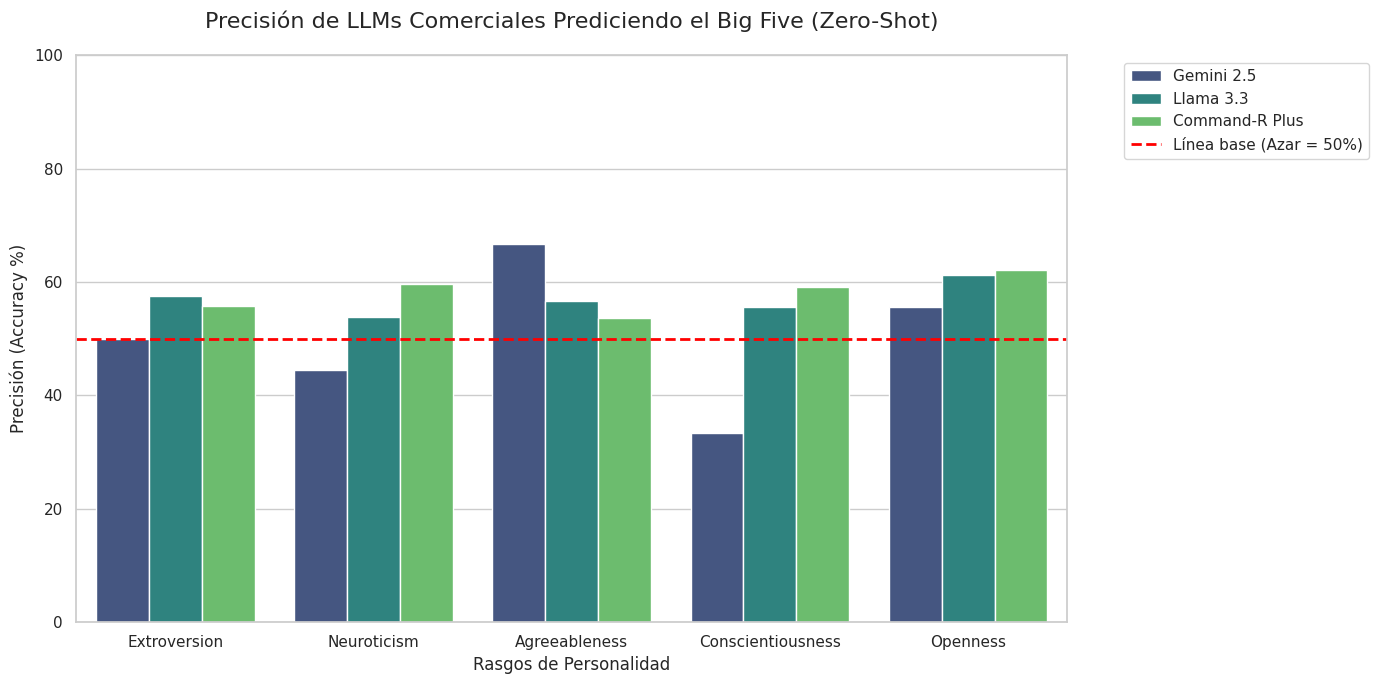

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo del gráfico
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Crear el gráfico de barras
grafico = sns.barplot(data=df_resultados, x='Rasgo', y='Accuracy (%)', hue='Modelo', palette="viridis")

# Añadir títulos y etiquetas
plt.title('Precisión de LLMs Comerciales Prediciendo el Big Five (Zero-Shot)', fontsize=16, pad=20)
plt.ylabel('Precisión (Accuracy %)', fontsize=12)
plt.xlabel('Rasgos de Personalidad', fontsize=12)
plt.ylim(0, 100) # El eje Y va de 0 a 100%

# Añadir la "Línea Base" del azar (50%)
plt.axhline(50, color='red', linestyle='--', linewidth=2, label='Línea base (Azar = 50%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Mover la leyenda afuera

# Mostrar el gráfico
plt.tight_layout()
plt.show()